### Visualisation

In [ ]:
# ── Setup & load high-confidence features ──────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Point this to your pLannotate summaries directory
# e.g. Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summaries")
BASE_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesgfp")

# Confidence thresholds and options
CONF_IDENTITY = 95.0
CONF_COVERAGE = 80.0
EXCLUDE_FRAGMENTS = True

# Plot options
TOP_K = 10
FIGSIZE = (6, 6)

# Load high-confidence table (preferred), else load all and filter here
hi_path  = BASE_DIR / "features_highconf.csv"
all_path = BASE_DIR / "features_all.csv"
if hi_path.exists():
    feats = pd.read_csv(hi_path)
else:
    feats = pd.read_csv(all_path)

# Enforce thresholds explicitly (no harm if it's already filtered)
feats["identity"] = pd.to_numeric(feats.get("identity"), errors="coerce")
feats["match_length"] = pd.to_numeric(feats.get("match_length"), errors="coerce")
if "fragment" in feats.columns:
    feats["fragment"] = feats["fragment"].astype(bool)
mask = (feats["identity"].fillna(0) >= CONF_IDENTITY) & \
       (feats["match_length"].fillna(0) >= CONF_COVERAGE)
if EXCLUDE_FRAGMENTS and "fragment" in feats.columns:
    mask &= ~feats["fragment"]
feats_conf = feats.loc[mask].copy()

print(f"Loaded {len(feats)} features; {len(feats_conf)} pass high-confidence filters.")
feats_conf.head(3)


Loaded 9151 features; 9151 pass high-confidence filters.


,plasmid_id,length_bp,topology,feature_type,label,note,database,other,fragment,identity,match_length,start,end,feat_len,strand,file
0,base_generated_000_pLann,4429,circular,CDS,hfriFP,pLannotate,fpbase,CDS,False,100.0,100.0,64,778,714,+,base_generated_000_pLann.gbk
1,base_generated_000_pLann,4429,circular,CDS,cat,pLannotate,swissprot,CDS,False,100.0,100.0,1072,1729,657,-,base_generated_000_pLann.gbk
2,base_generated_000_pLann,4429,circular,promoter,AmpR promoter,pLannotate,snapgene,promoter,False,100.0,100.0,3384,3489,105,+,base_generated_000_pLann.gbk


In [2]:
# ── Radar plot helper ──────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def radar_plot(labels, values, title, figsize=(6,6), savepath=None):
    """
    Simple radar chart using matplotlib (no explicit colors).
    labels: list[str]
    values: list[float] (percentages recommended). The polygon is closed automatically.
    """
    labels = list(labels)
    values = list(values)
    if len(labels) == 0:
        print(f"[INFO] No data to plot for: {title}")
        return

    # Angles around the circle
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

    # Close the polygon
    angles += angles[:1]
    values += values[:1]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_rlabel_position(0)
    ax.set_title(title, pad=20)

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"Saved: {savepath}")

    plt.show()


,count,percent
abx_key,,
KanR,237,37.98
AmpR,209,33.49
cat,76,12.18
TetR,35,5.61
CmR,18,2.88
aadA,13,2.08
bla,11,1.76
SmR,11,1.76
tetR,8,1.28


Saved: /cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/radar_abx_highconf.png


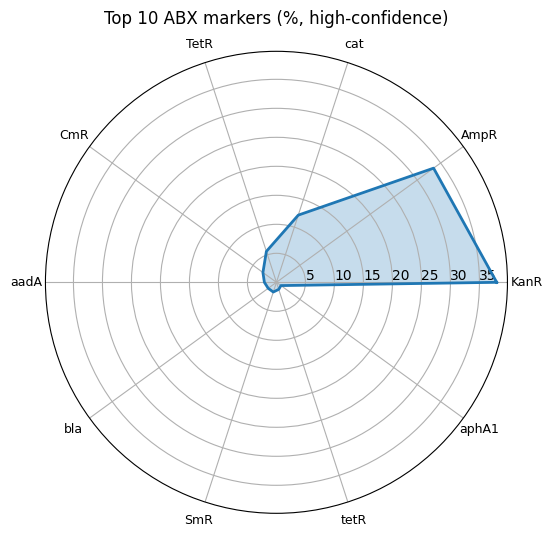

In [3]:
# ── ABX markers radar (from CDS labels) ────────────────────────────────
ABX_PATTERNS = [
    "ampr", "bla", "beta-lactamase",
    "kanr", "neor", "aph", "npt",
    "cmr", "cat",
    "specr", "smr", "aada",
    "tetr", "teta", "tetr",
    "hygro", "hygr",
    "zeo", "zeor",
    "gmr", "gent", "aac",
]

cds = feats_conf[feats_conf.get("feature_type", "") == "CDS"].copy()
cds["label_lc"] = cds["label"].fillna("").str.lower()

def is_abx_label(s, patterns):
    s = s or ""
    return any(p in s for p in patterns)

abx_df = cds[cds["label_lc"].apply(lambda s: is_abx_label(s, [p.lower() for p in ABX_PATTERNS]))].copy()

# Canonical key: prefer the original 'label'; fall back to first matching pattern
def first_pattern(s, patterns):
    for p in patterns:
        if p in s:
            return p
    return "unknown"

abx_df["abx_key"] = abx_df["label"].fillna("").astype(str)
empty = abx_df["abx_key"].str.strip().eq("")
abx_df.loc[empty, "abx_key"] = abx_df.loc[empty, "label_lc"].apply(lambda s: first_pattern(s, [p.lower() for p in ABX_PATTERNS]))

abx_counts = abx_df["abx_key"].value_counts().head(TOP_K)
abx_labels = abx_counts.index.tolist()
abx_values = (abx_counts / abx_counts.sum() * 100.0).round(2).tolist()

display(abx_counts.to_frame("count").assign(percent=lambda d: (d["count"]/d["count"].sum()*100).round(2)))

radar_plot(
    abx_labels,
    abx_values,
    f"Top {len(abx_labels)} ABX markers (%, high-confidence)",
    figsize=FIGSIZE,
    savepath=BASE_DIR / "radar_abx_highconf.png"
)


,count,percent
ori_key,,
ori,434,45.35
pBBR1 oriV,327,34.17
f1 ori,85,8.88
p15A ori,75,7.84
pSC101 ori,13,1.36
SV40 ori,5,0.52
2μ ori,5,0.52
oriV,5,0.52
RSF ori,4,0.42


Saved: /cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/radar_ori_highconf.png


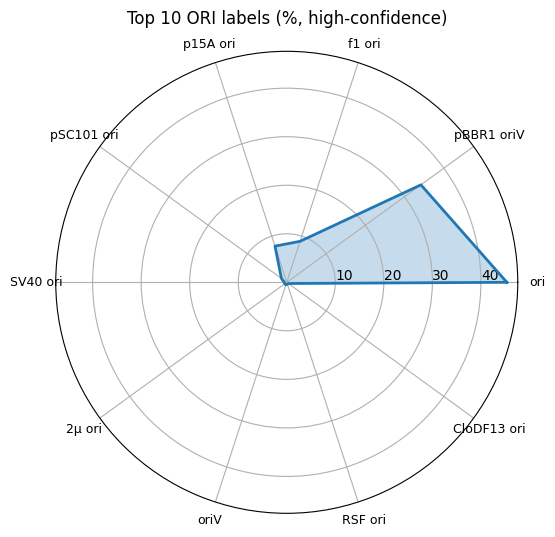

In [4]:
# ── ORI labels radar (from rep_origin features) ────────────────────────
oris = feats_conf[feats_conf.get("feature_type", "") == "rep_origin"].copy()
oris["ori_key"] = oris["label"].fillna("unknown").astype(str)

ori_counts = oris["ori_key"].value_counts().head(TOP_K)
ori_labels = ori_counts.index.tolist()
ori_values = (ori_counts / ori_counts.sum() * 100.0).round(2).tolist()

display(ori_counts.to_frame("count").assign(percent=lambda d: (d["count"]/d["count"].sum()*100).round(2)))

radar_plot(
    ori_labels,
    ori_values,
    f"Top {len(ori_labels)} ORI labels (%, high-confidence)",
    figsize=FIGSIZE,
    savepath=BASE_DIR / "radar_ori_highconf.png"
)


### Quality control

In [5]:
# ── QC config & load ───────────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np

# If BASE_DIR not set above, set it here:
# BASE_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summaries")

# Identity thresholds
ORI_MIN_IDENTITY = 95.0
OTHER_MIN_IDENTITY = 95.0
ABX_MIN_IDENTITY = 99.0

# Only count "full" features
REQUIRE_NON_FRAGMENT = True

# ABX patterns (lowercased substring search on CDS labels)
ABX_PATTERNS = [
    "ampr", "bla", "beta-lactamase",
    "kanr", "neor", "aph", "npt",
    "cmr", "cat",
    "specr", "smr", "aada",
    "tetr", "teta", "tetr",
    "hygro", "hygr",
    "zeo", "zeor",
    "gmr", "gent", "aac",
]

# Load features if not present
try:
    feats
except NameError:
    feats = pd.read_csv(BASE_DIR / "features_all.csv")

# Coerce expected columns
feats["identity"] = pd.to_numeric(feats.get("identity"), errors="coerce")
if "fragment" in feats.columns:
    feats["fragment"] = feats["fragment"].astype(bool)
else:
    feats["fragment"] = False

# Normalize helper columns
feats["feature_type"] = feats["feature_type"].astype(str)
feats["plasmid_id"]  = feats["plasmid_id"].astype(str)
feats["label"]       = feats["label"].fillna("").astype(str)
feats["label_lc"]    = feats["label"].str.lower().str.strip()

print(f"Loaded {len(feats)} feature rows across {feats['plasmid_id'].nunique()} plasmids.")


Loaded 9151 feature rows across 1000 plasmids.


In [6]:
# ── Build category views according to your identity + "full feature" rules ──

# ORIs (rep_origin), >95% identity, non-fragment
ori_df = feats[(feats["feature_type"] == "rep_origin") &
               (feats["identity"].fillna(0) >= ORI_MIN_IDENTITY)]
if REQUIRE_NON_FRAGMENT:
    ori_df = ori_df[~ori_df["fragment"]]

# ABX (CDS with ABX pattern), >99% identity, non-fragment
is_abx_cds = feats["feature_type"].eq("CDS") & feats["label_lc"].apply(
    lambda s: any(p in s for p in [p.lower() for p in ABX_PATTERNS])
)
abx_df = feats[is_abx_cds & (feats["identity"].fillna(0) >= ABX_MIN_IDENTITY)]
if REQUIRE_NON_FRAGMENT:
    abx_df = abx_df[~abx_df["fragment"]]

# For "repeated features" rule we check duplicates **by label** within a plasmid
# for these categories: ORIs, ABX, and terminators (as per your example).
term_df = feats[(feats["feature_type"] == "terminator") &
                (feats["identity"].fillna(0) >= OTHER_MIN_IDENTITY)]
if REQUIRE_NON_FRAGMENT:
    term_df = term_df[~term_df["fragment"]]

print(f"ORIs (eligible): {len(ori_df)} rows")
print(f"ABX  (eligible): {len(abx_df)} rows")
print(f"Terms(eligible): {len(term_df)} rows")


ORIs (eligible): 960 rows
ABX  (eligible): 625 rows
Terms(eligible): 3449 rows


In [7]:
# ── QC logic per plasmid ────────────────────────────────────────────────

def find_repeats(df, group_cols=("plasmid_id",), label_col="label_lc"):
    """Return a dict: plasmid_id -> list of labels that repeat (count >= 2)."""
    if df.empty:
        return {}
    grp = df.groupby(list(group_cols) + [label_col]).size().rename("n").reset_index()
    reps = grp[grp["n"] >= 2]
    out = {}
    for pid, sub in reps.groupby("plasmid_id"):
        out[pid] = sorted(sub[label_col].tolist())
    return out

# Precompute counts
ori_counts = ori_df.groupby("plasmid_id").size().rename("ori_count")
abx_counts = abx_df.groupby("plasmid_id").size().rename("abx_count")

# Repeats (by label within plasmid)
ori_repeats  = find_repeats(ori_df)
abx_repeats  = find_repeats(abx_df)
term_repeats = find_repeats(term_df)

# Universe of plasmids to QC = union present in feats
all_pids = sorted(feats["plasmid_id"].unique().tolist())

records = []
for pid in all_pids:
    oc = int(ori_counts.get(pid, 0))
    ac = int(abx_counts.get(pid, 0))

    reasons = []

    # ORI rule: exactly one
    if oc == 0:
        reasons.append("No ORI")
    elif oc > 1:
        reasons.append(f"Multiple ORIs (n={oc})")

    # ABX rule: 1 or 2
    if ac == 0:
        reasons.append("No ABX")
    elif ac > 2:
        reasons.append(f"Too many ABX (n={ac})")

    # No repeated features by label within category
    if pid in ori_repeats and len(ori_repeats[pid]) > 0:
        reasons.append("Repeated ORI labels: " + ", ".join(sorted(set(ori_repeats[pid]))))
    if pid in abx_repeats and len(abx_repeats[pid]) > 0:
        reasons.append("Repeated ABX labels: " + ", ".join(sorted(set(abx_repeats[pid]))))
    if pid in term_repeats and len(term_repeats[pid]) > 0:
        reasons.append("Repeated terminator labels: " + ", ".join(sorted(set(term_repeats[pid]))))

    passed = (len(reasons) == 0)

    records.append({
        "plasmid_id": pid,
        "ori_count": oc,
        "abx_count": ac,
        "passed_qc": passed,
        "fail_reasons": "; ".join(reasons) if reasons else "",
    })

qc_df = pd.DataFrame.from_records(records).sort_values(["passed_qc","plasmid_id"], ascending=[False, True]).reset_index(drop=True)
display(qc_df.head(10))

# Save per-plasmid QC table
qc_path = BASE_DIR / "qc_per_plasmid.csv"
qc_df.to_csv(qc_path, index=False)
print(f"Saved per-plasmid QC table → {qc_path}")


,plasmid_id,ori_count,abx_count,passed_qc,fail_reasons
0,base_generated_000_pLann,1,2,True,
1,base_generated_007_pLann,1,1,True,
2,base_generated_008_pLann,1,1,True,
3,base_generated_009_pLann,1,1,True,
4,base_generated_010_pLann,1,1,True,
5,base_generated_011_pLann,1,1,True,
6,base_generated_012_pLann,1,1,True,
7,base_generated_013_pLann,1,1,True,
8,base_generated_016_pLann,1,1,True,
9,base_generated_018_pLann,1,1,True,


Saved per-plasmid QC table → /cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/qc_per_plasmid.csv


In [8]:
# ── Summary tables ─────────────────────────────────────────────────────
total = len(qc_df)
passed = int(qc_df["passed_qc"].sum())
failed = total - passed
print(f"Total plasmids: {total}\nPassed QC: {passed}\nFailed QC: {failed}")

# Explode reasons into rows for counting
reason_rows = []
for _, r in qc_df[~qc_df["passed_qc"]].iterrows():
    reasons = [x.strip() for x in r["fail_reasons"].split(";") if x.strip()]
    if not reasons:
        reasons = ["(unspecified)"]
    for reason in reasons:
        reason_rows.append({"reason": reason, "plasmid_id": r["plasmid_id"]})

reason_df = pd.DataFrame(reason_rows)
if len(reason_df):
    reason_counts = reason_df.groupby("reason").size().rename("count").reset_index().sort_values("count", ascending=False)
else:
    reason_counts = pd.DataFrame(columns=["reason","count"])

display(reason_counts)

# Save summary
summary_path = BASE_DIR / "qc_failure_reasons.csv"
reason_counts.to_csv(summary_path, index=False)
print(f"Saved reason summary → {summary_path}")


Total plasmids: 1000
Passed QC: 249
Failed QC: 751


,reason,count
2,No ABX,411
3,No ORI,194
16,Repeated terminator labels: rrnb t1 terminator...,165
0,Multiple ORIs (n=2),148
14,Repeated terminator labels: rrnb t1 terminator,145
8,Repeated ORI labels: ori,33
13,Repeated terminator labels: lambda t0 terminat...,12
20,Repeated terminator labels: t7te terminator,10
12,Repeated terminator labels: lambda t0 terminat...,4
17,Repeated terminator labels: rrnb t1 terminator...,4


Saved reason summary → /cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/qc_failure_reasons.csv


/tmp/ipykernel_8839/1313704054.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


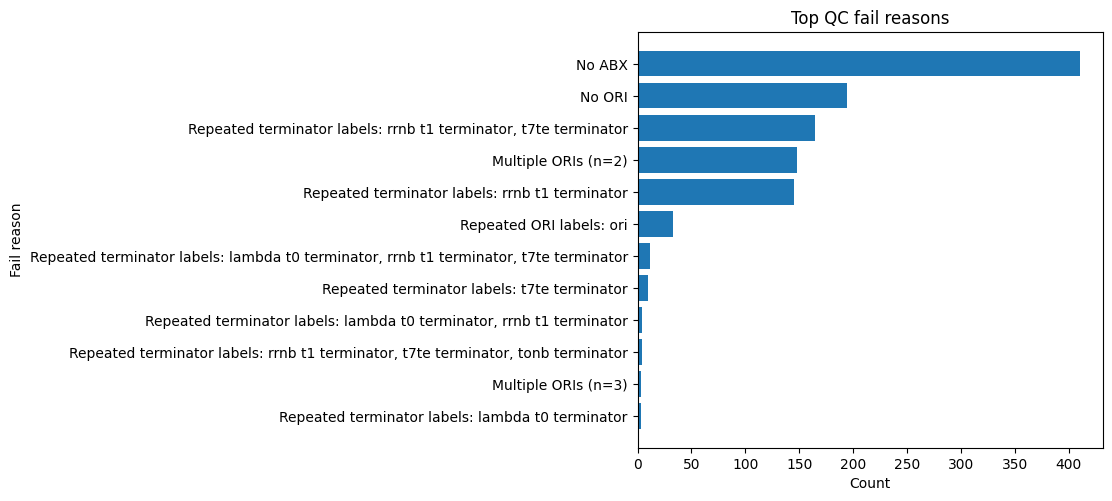

,reason,count
0,No ABX,411
1,No ORI,194
2,Repeated terminator labels: rrnb t1 terminator...,165
3,Multiple ORIs (n=2),148
4,Repeated terminator labels: rrnb t1 terminator,145
5,Repeated ORI labels: ori,33
6,Repeated terminator labels: lambda t0 terminat...,12
7,Repeated terminator labels: t7te terminator,10
8,Repeated terminator labels: lambda t0 terminat...,4
9,Repeated terminator labels: rrnb t1 terminator...,4


In [9]:
# ── Top QC fail reasons (bar chart) ────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild reason_counts if it isn't already in memory
if "reason_counts" not in globals():
    reason_rows = []
    for _, r in qc_df[~qc_df["passed_qc"]].iterrows():
        reasons = [x.strip() for x in str(r["fail_reasons"]).split(";") if x.strip()]
        if not reasons:
            reasons = ["(unspecified)"]
        for reason in reasons:
            reason_rows.append({"reason": reason})

    reason_df = pd.DataFrame(reason_rows)
    if len(reason_df):
        reason_counts = (
            reason_df.groupby("reason").size().rename("count").reset_index()
            .sort_values("count", ascending=False)
        )
    else:
        reason_counts = pd.DataFrame(columns=["reason", "count"])

TOP_N_REASONS = 12
rc = reason_counts.head(TOP_N_REASONS)

fig = plt.figure(figsize=(6, max(3, 0.45*len(rc))))
ax = plt.gca()
ax.barh(rc["reason"], rc["count"])
ax.set_xlabel("Count")
ax.set_ylabel("Fail reason")
ax.set_title("Top QC fail reasons")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(rc.reset_index(drop=True))


In [ ]:
# ── Strict high-confidence filter (pident/percmatch-aware) ─────────────
import re
import numpy as np
import pandas as pd

ENFORCE_ABX_99 = False
ABX_PATTERNS = [
    "ampr","bla","beta-lactamase","kanr","neor","aph","npt","cmr","cat",
    "specr","smr","aada","tetr","teta","tetr","hygro","hygr","zeo","zeor",
    "gmr","gent","aac"
]

MIN_ID  = 95.0
ABX_ID  = 99.0
MIN_COV = 80.0
EXCLUDE_FRAGMENTS = True

def _norm(s): return re.sub(r'[^a-z0-9]', '', str(s).lower())

def pick_col(df, candidates):
    """Fuzzy-pick a column name by normalized exact, then substring."""
    norm_map = {c: _norm(c) for c in df.columns}
    wants = [_norm(c) for c in candidates]
    for want in wants:
        for c, n in norm_map.items():
            if n == want:
                return c
    for want in wants:
        for c, n in norm_map.items():
            if want in n:
                return c
    return None

def to_percent_series(s):
    """
    Parse numbers like 97.5, '97.5%', ' 97.5 % ', or 0.975 into 0..100.
    Heuristic: if most values <= 1, treat as fraction and scale*100.
    """
    s = s.astype(str)
    extracted = s.str.extract(r'([-+]?\d*\.?\d+)', expand=False)
    vals = pd.to_numeric(extracted, errors="coerce")
    if vals.notna().any():
        if (vals.dropna() <= 1.0).mean() >= 0.8:
            vals = vals * 100.0
    return vals

def highconf_hits_strict(h,
                         min_id=MIN_ID,
                         min_cov=MIN_COV,
                         exclude_fragments=EXCLUDE_FRAGMENTS,
                         enforce_abx_99=ENFORCE_ABX_99,
                         abx_patterns=ABX_PATTERNS):
    h = h.copy()

    # Resolve columns (identity prefers BLAST pident)
    id_col  = pick_col(h, [
        "pident","percent_identity","perc_identity","identity","identity(%)",
        "identity_percent","pct_identity","pctid","pi_permatch"
    ])

    # Coverage: prefer explicit % if present; else compute 100*length/qlen
    cov_col = pick_col(h, [
        "percmatch","abs percmatch","match_length","coverage",
        "percent_coverage","pct_coverage","coverage(%)"
    ])
    has_len = pick_col(h, ["length","align_len","aln_len"])
    has_qln = pick_col(h, ["qlen","query_len","query_length"])

    frag_col = pick_col(h, ["fragment","is_fragment","frag"])

    # ---- Identity
    if id_col is None:
        raise KeyError(f"Could not find an identity column among: {list(h.columns)}")
    h[id_col] = to_percent_series(h[id_col])

    # ---- Coverage
    if cov_col is not None:
        h[cov_col] = to_percent_series(h[cov_col])
    elif has_len is not None and has_qln is not None:
        # compute query coverage in %
        cov_col = "_cov_pct"
        h[cov_col] = pd.to_numeric(h[has_len], errors="coerce") / pd.to_numeric(h[has_qln], errors="coerce") * 100.0
    else:
        raise KeyError("Could not determine coverage: no percmatch/coverage column and no (length, qlen) to compute it.")

    # ---- Fragments
    if frag_col is not None:
        h[frag_col] = (
            h[frag_col].astype(str).str.strip().str.lower()
              .map({"true": True, "false": False, "1": True, "0": False})
              .fillna(False).astype(bool)
        )
    else:
        h["_frag"] = False
        frag_col = "_frag"

    # ---- Base mask
    mask = pd.Series(True, index=h.index)
    if exclude_fragments:
        mask &= ~h[frag_col]
    mask &= h[id_col].fillna(0)  >= float(min_id)
    mask &= h[cov_col].fillna(0) >= float(min_cov)

    # ---- Optional ABX=99%
    if enforce_abx_99:
        # Choose a label-like column to pattern-match (label/Feature/Description)
        label_col = pick_col(h, ["label","Feature","Description","gene","Name"])
        lbl = h[label_col].astype(str).str.lower() if label_col else pd.Series("", index=h.index)

        ftype_col = pick_col(h, ["feature_type","Type","type","feat_type"])
        ftype = h[ftype_col].astype(str) if ftype_col else pd.Series("", index=h.index)

        pat = re.compile("|".join(map(re.escape, [p.lower() for p in abx_patterns]))) if abx_patterns else None
        is_abx = ftype.str.upper().eq("CDS") & (lbl.str.contains(pat) if pat else False)

        mask &= ~(is_abx & (h[id_col].fillna(0) < float(ABX_ID)))

    filtered = h.loc[mask].copy()

    # Optional: quick sanity print to verify which columns were used
    used = {"identity_col": id_col, "coverage_col": cov_col, "fragment_col": frag_col}
    print("High-conf using:", used, f"→ kept {len(filtered)}/{len(h)} rows")
    return filtered


In [12]:
# ── Use strict filter in plotting loop ─────────────────────────────────
from bokeh.io import reset_output, output_notebook, show
from bokeh.embed import file_html
from bokeh.resources import CDN
from Bio import SeqIO
from pathlib import Path

# Ensure these are set (adapt to your paths)
GBK_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/plan_basegfp2")
MAP_DIR = BASE_DIR / "maps"
MAP_DIR.mkdir(parents=True, exist_ok=True)

from plannotate_wrapper import run_plannotate_sequence
from plannotate.bokeh_plot import get_bokeh

output_notebook()

for _, r in top3.iterrows():
    pid = r["plasmid_id"]
    # Resolve file path
    cand = []
    if pd.notna(r.get("file")) and str(r["file"]).strip():
        cand.append(GBK_DIR / str(r["file"]))
    cand += [GBK_DIR / f"{pid}.gb", GBK_DIR / f"{pid}.gbk"]
    gbk_path = next((p for p in cand if p.exists()), None)
    assert gbk_path is not None, f"Could not locate GenBank file for {pid} in {GBK_DIR}"

    rec = SeqIO.read(str(gbk_path), "genbank")
    is_linear = (rec.annotations.get("topology","").lower() == "linear")

    # Get hits and apply STRICT filter
    hits_df, seq_record, plot = run_plannotate_sequence(
        seq_or_filepath=str(gbk_path),
        output_html=None,
        is_detailed=False,
        linear=is_linear,
        yaml_file=None
    )

    hits_hi = highconf_hits_strict(
        hits_df,
        min_id=MIN_ID,
        min_cov=MIN_COV,
        exclude_fragments=EXCLUDE_FRAGMENTS,
        enforce_abx_99=ENFORCE_ABX_99,  # set True above if you want 99% for ABX
    )

    print(f"{pid}: plotting {len(hits_hi)} high-confidence hits out of {len(hits_df)} total.")
    if hits_hi.empty:
        print(f"  ⚠ No features meet the high-confidence criteria for {pid}. Skipping plot.")
        continue

    reset_output(); output_notebook()
    plot2 = get_bokeh(hits_hi, linear=is_linear)
    show(plot2)

    html_out = MAP_DIR / f"{pid}_map_highconf.html"
    html_out.write_text(file_html(plot2, CDN, f"pLannotate (high-confidence): {pid}"))
    print(f"Saved → {html_out}")


Loading BokehJS ...

2025-09-15 10:48:52.303 
  command:

    streamlit run /cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
/cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/plannotate/infernal.py:68: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  infernal = infernal.apply(pd.to_numeric, errors="ignore", downcast="integer")
/cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/plannotate/infernal.py:78: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  infernal["sframe"] = infernal["sframe"].replace(["

High-conf using: {'identity_col': 'pident', 'coverage_col': 'percmatch', 'fragment_col': 'fragment'} → kept 8/10 rows
base_generated_893_pLann: plotting 8 high-confidence hits out of 10 total.


/cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/plannotate/bokeh_plot.py:343: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_orientation"] = df["has_orientation"].fillna(value=False).infer_objects()


Loading BokehJS ...

...

High-conf using: {'identity_col': 'pident', 'coverage_col': 'percmatch', 'fragment_col': 'fragment'} → kept 8/12 rows
base_generated_510_pLann: plotting 8 high-confidence hits out of 12 total.


/cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/plannotate/bokeh_plot.py:343: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_orientation"] = df["has_orientation"].fillna(value=False).infer_objects()


Loading BokehJS ...

/cs/student/projects1/aibh/2024/acunning/miniconda3/envs/clean-env/lib/python3.10/site-packages/plannotate/bokeh_plot.py:343: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_orientation"] = df["has_orientation"].fillna(value=False).infer_objects()


Saved → /cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/maps/base_generated_510_pLann_map_highconf.html


In [14]:
import os
import shutil
import pandas as pd
from pathlib import Path

# ─── Paths ───────────────────────────────────────────
qc_csv = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/qc_per_plasmid.csv")
fasta_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/gen_basegfp2")
out_dir = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfp_passed")

# ─── Make sure output directory exists ───────────────
out_dir.mkdir(parents=True, exist_ok=True)

# ─── Read QC CSV ─────────────────────────────────────
qc_df = pd.read_csv(qc_csv)

# ─── Filter for passed sequences ─────────────────────
passed_df = qc_df[qc_df["passed_qc"] == True]

print(f"Found {len(passed_df)} sequences that passed QC.")

# ─── Copy corresponding FASTA files ──────────────────
for plasmid_id in passed_df["plasmid_id"]:
    # remove trailing "_pLann" if present
    base_id = plasmid_id.replace("_pLann", "")
    fasta_file = fasta_dir / f"{base_id}.fasta"

    if fasta_file.exists():
        shutil.copy(fasta_file, out_dir / fasta_file.name)
    else:
        print(f"⚠️ Missing FASTA file for {base_id}")

print("✅ Copy complete.")



Found 249 sequences that passed QC.
✅ Copy complete.


In [15]:
from pathlib import Path
import pandas as pd

# --- paths & threshold ---
CSV_PATH   = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/longest_repeats.csv")
PASSED_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed")
THRESHOLD_BP = 50

# load & filter
df = pd.read_csv(CSV_PATH)
df["longest_len"] = pd.to_numeric(df["longest_len"], errors="coerce").fillna(0)
files = set(Path(p) for p in df.loc[df["longest_len"] > THRESHOLD_BP, "file"].dropna().astype(str))

# delete files (only if inside PASSED_DIR for safety)
passed_root = PASSED_DIR.resolve()
deleted = 0
for p in files:
    try:
        rp = p.resolve()
    except FileNotFoundError:
        continue
    if rp.is_file() and (passed_root in rp.parents):
        rp.unlink(missing_ok=True)
        deleted += 1

print(f"Deleted {deleted} files from {PASSED_DIR} where longest_len > {THRESHOLD_BP} bp.")


Deleted 51 files from /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed where longest_len > 50 bp.


In [16]:
import os
import pandas as pd
from pathlib import Path

# Paths
QC_PASSED_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed")
FEATURES_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/features_highconf.csv")
OUTPUT_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/metadata_qcpassed.csv")

# Get list of QC passed sequences (remove .fasta extension)
qc_passed_ids = {
    Path(f).stem.replace("_pLann", "") 
    for f in os.listdir(QC_PASSED_DIR) 
    if f.endswith('.fasta')
}

# Read features CSV
features_df = pd.read_csv(FEATURES_CSV)

# Filter for only QC passed sequences
# Add _pLann back to match the plasmid_id format in features file
passed_features = features_df[
    features_df['plasmid_id'].apply(
        lambda x: x.replace("_pLann", "") in qc_passed_ids
    )
]

# Save filtered metadata
passed_features.to_csv(OUTPUT_CSV, index=False)
print(f"Created metadata for {len(qc_passed_ids)} QC-passed sequences → {OUTPUT_CSV}")

Created metadata for 198 QC-passed sequences → /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/metadata_qcpassed.csv


In [22]:
import pandas as pd
from pathlib import Path

# Paths
FEATURES_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/plannotate/summariesbasegfp/features_highconf.csv")
OUTPUT_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/please_qc_passed.csv")

# Load features
features_df = pd.read_csv(FEATURES_CSV)

# Group by plasmid to get sequence lengths
lengths = features_df.groupby('plasmid_id')['length_bp'].first()

# Function to check if a plasmid meets all criteria
def meets_criteria(pid):
    plasmid_feats = features_df[features_df['plasmid_id'] == pid]
    
    # Check length <= 4000bp
    if lengths[pid] > 4000:
        return False
    
    # Check for ABR gene with 100% identity
    abr_present = any(
        (plasmid_feats['feature_type'] == 'CDS') &
        (plasmid_feats['identity'] >= 99.0) &
        plasmid_feats['label'].str.contains(
            'AmpR|KanR|CmR|TetR|SmR|cat|aph|bla|aada|aac', 
            case=False, 
            regex=True
        )
    )
    if not abr_present:
        return False
    
    # Check for ori/pBBR1 with ≥99% identity
    ori_present = any(
        (plasmid_feats['feature_type'] == 'rep_origin') &
        (plasmid_feats['identity'] >= 99.0) &
        (
            plasmid_feats['label'].str.contains('ori', case=False, regex=True)
        )
    )
    if not ori_present:
        return False
    
    return True

# Apply criteria to all plasmids
passed_plasmids = []
for pid in features_df['plasmid_id'].unique():
    if meets_criteria(pid):
        passed_plasmids.append({
            'plasmid_id': pid,
            'length_bp': lengths[pid]
        })

# Create and save results
results_df = pd.DataFrame(passed_plasmids)
results_df.to_csv(OUTPUT_CSV, index=False)

print(f"Found {len(passed_plasmids)} sequences passing strict QC criteria:")
print(f"- Length ≤ 4000bp")
print(f"- Contains ABR gene with 100% identity")
print(f"- Contains ori/pBBR1 with ≥99% identity")
print(f"\nSaved results to: {OUTPUT_CSV}")

Found 173 sequences passing strict QC criteria:
- Length ≤ 4000bp
- Contains ABR gene with 100% identity
- Contains ori/pBBR1 with ≥99% identity

Saved results to: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/please_qc_passed.csv


In [20]:
import pandas as pd
import shutil
from pathlib import Path

# Define paths
STRICT_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/strictish_qc_passed.csv")
SOURCE_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed")
TARGET_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/STRICTgfp_passed")

# Create target directory
TARGET_DIR.mkdir(parents=True, exist_ok=True)

# Read the strict QC results
strict_df = pd.read_csv(STRICT_CSV)

# Get list of plasmid IDs that passed strict QC
passed_ids = [pid.replace("_pLann", "") for pid in strict_df['plasmid_id']]

# Copy matching FASTA files
copied = 0
for pid in passed_ids:
    source_file = SOURCE_DIR / f"{pid}.fasta"
    if source_file.exists():
        shutil.copy2(source_file, TARGET_DIR)
        copied += 1
    else:
        print(f"⚠️ Missing source file: {source_file}")

print(f"✅ Copied {copied}/{len(passed_ids)} FASTA files to {TARGET_DIR}")

⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_014.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_122.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_138.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_147.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_151.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_153.fasta
⚠️ Missing source file: /cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/basegfppass/basegfp_passed/base_generated_16

In [21]:
df = pd.read_csv('/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/strict_qc_passed.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   plasmid_id  30 non-null     object
 1   length_bp   30 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 608.0+ bytes
